In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("./fashion-mnist_test.csv")

In [4]:
df = df.drop(['label'], axis=1)


In [5]:
arr = df.to_numpy('uint8')

In [6]:
arr.shape, arr.dtype

((10000, 784), dtype('uint8'))

In [7]:

def stitch_images(data, pixel_height, pixel_width, img_dim=28):
    """
    data: np.ndarray of shape (N, img_dim**2)
    pixel_height: target height in pixels
    pixel_width: target width in pixels
    """
    # 1. Calculate necessary grid size
    grid_rows = int(np.ceil(pixel_height / img_dim))
    grid_cols = int(np.ceil(pixel_width / img_dim))
    n_images = grid_rows * grid_cols
    
    # 2. Grab and reshape subset
    rng = np.random.default_rng()
    subset = rng.choice(data, size=n_images, replace=True, axis=0).reshape(n_images, img_dim, img_dim)
    
    # 3. Reshape into grid structure
    grid = subset.reshape(grid_rows, grid_cols, img_dim, img_dim)
    
    # 4. Transpose and reshape to create the full image
    # We transpose to (rows, img_h, cols, img_w) then reshape to merge the dims
    stitched = grid.transpose(0, 2, 1, 3).reshape(grid_rows * img_dim, grid_cols * img_dim)
    
    # 5. Crop to the exact pixel dimensions requested
    cropped = stitched[:pixel_height, :pixel_width]
    return cropped.ravel()


In [8]:
stiched_image = stitch_images(arr, 28, 56)

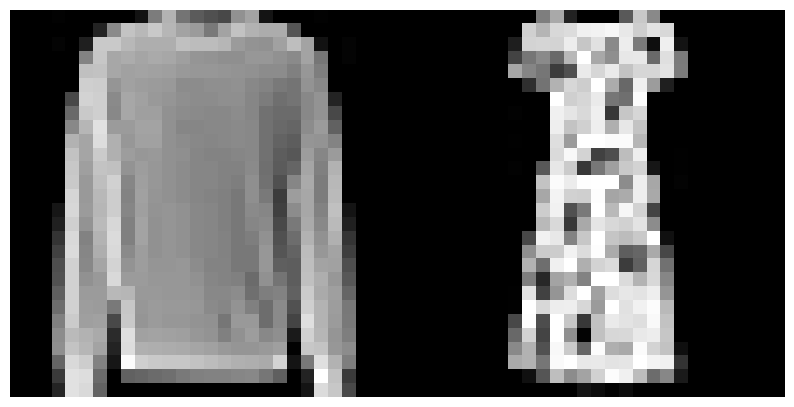

In [9]:
import matplotlib.pyplot as plt

def show_stitched_image(data_1d, total_height, total_width):
    # 1. Calculate the final 2D dimensions

    # 2. Reshape the 1D byte array into a 2D matrix
    image_2d = data_1d.reshape(total_height, total_width)
    
    # 3. Plot it
    plt.figure(figsize=(10, 10))
    # Use cmap='gray' since these are greyscale intensities
    plt.imshow(image_2d, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')  # Hide the pixel coordinate axes
    plt.show()

# Example Usage:
# large_image_data = stitch_images(my_data, 5, 5)
# show_stitched_image(large_image_data, 5, 5)
show_stitched_image(stiched_image, 28,56)

In [10]:
from sobel_reference import sobel_reference

In [11]:
magnitude, direction = sobel_reference(stiched_image.reshape(28,56))

In [12]:
magnitude.shape

(26, 54)

In [13]:
print(magnitude.min(), magnitude.max())

print(direction.min(), direction.max(), np.pi)

0.0 1023.41876
-3.136898 3.1415927 3.141592653589793


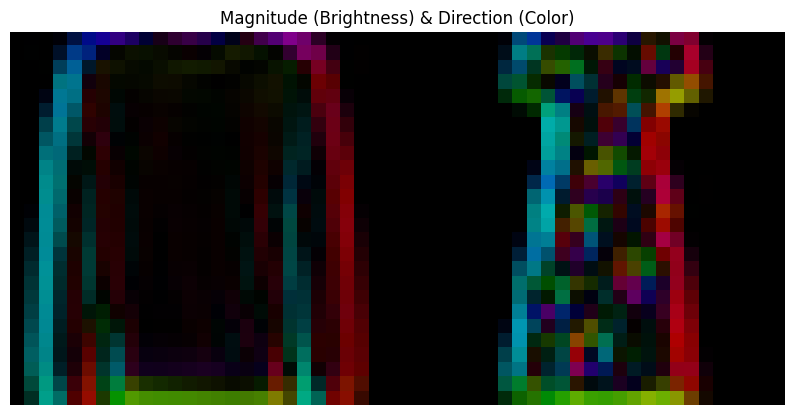

In [14]:
from matplotlib.colors import hsv_to_rgb
def visualize_vector_field(mag, direction, h, w):
    """
    mag: 2D array of floats (0-255)
    direction: 2D array of floats (-pi to pi)
    """
    MAX_SOBEL_VALUE = np.sqrt(2) * 4 * 255 # when gx,gy = 255; technically over esimate
    mag = mag/MAX_SOBEL_VALUE*255
    
    mag = mag.reshape(h,w)

    direction = direction.reshape(h,w)
    
    # 1. Create an empty HSV image
    # Shape: (height, width, 3)
    hsv = np.zeros((h, w, 3), dtype=np.float32)
    
    # 2. Map Direction to Hue [0, 1]
    # We shift -pi...pi to 0...2pi, then normalize to 0...1
    hsv[..., 0] = (direction + np.pi) / (2 * np.pi)
    
    # 3. Set Saturation to maximum
    hsv[..., 1] = 1.0
    
    # 4. Map Magnitude to Value [0, 1]
    # Ensure it's clipped and normalized
    hsv[..., 2] = np.clip(mag, 0, 255) / 255.0
    
    # 5. Convert HSV to RGB for display
    rgb = hsv_to_rgb(hsv)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb)
    plt.title("Magnitude (Brightness) & Direction (Color)")
    plt.axis('off')
    plt.show()
visualize_vector_field(magnitude, direction, 28-2, 2*28-2)

In [15]:
stiched_image.tofile("stitched_image.img.bin")
combined_floats = np.concatenate([magnitude, direction]).astype("float32")
combined_floats.tofile("kernel_results.magdir.bin")

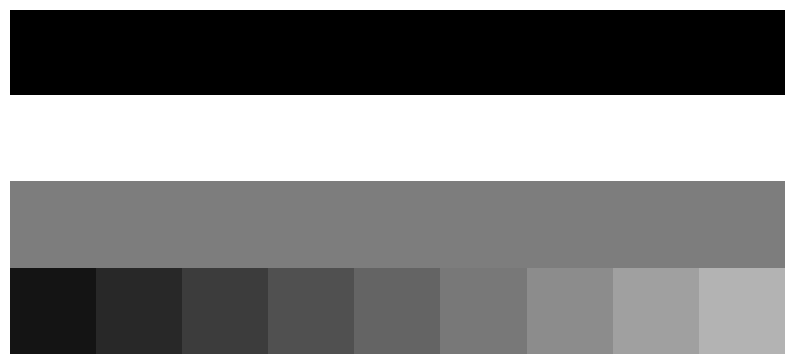

In [26]:
calibrate_4_9 = np.array([
    0,0,0, 0,0,0, 0,0,0,
    255,255,255, 255,255,255, 255,255,255, 
    125, 125, 125, 125, 125, 125, 125, 125, 125, 
    20, 40, 60, 80, 100, 120, 140, 160, 180 
    ])
show_stitched_image(calibrate_4_9, 4,9)

In [27]:
mag, dir = sobel_reference(calibrate_4_9.reshape(4,9))

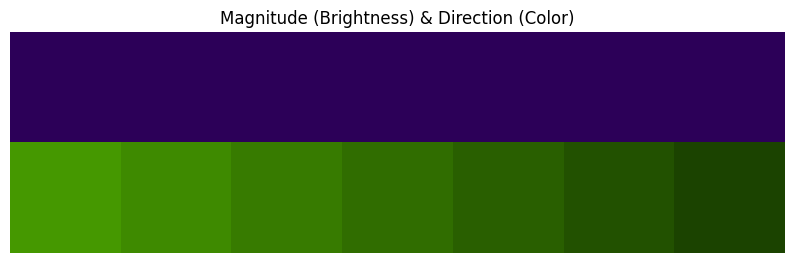

In [28]:
visualize_vector_field(mag,dir, 2, 7)

In [38]:
calibrate_4_9.flatten().astype(np.uint8).tofile("./data/calibrate_4_9.img.bin")
print(calibrate_4_9.flatten())
combined_floats = np.concatenate([mag,dir]).flatten().astype("float32")
print(combined_floats)
combined_floats.tofile("./data/calibrate_4_9.magdir.bin")

[  0   0   0   0   0   0   0   0   0 255 255 255 255 255 255 255 255 255
 125 125 125 125 125 125 125 125 125  20  40  60  80 100 120 140 160 180]
[500.        500.        500.        500.        500.        500.
 500.        860.92975   781.02496   701.1419    621.289     541.47943
 461.73587   382.09946     1.5707964   1.5707964   1.5707964   1.5707964
   1.5707964   1.5707964   1.5707964  -1.5243182  -1.5195591  -1.5137156
  -1.5063695  -1.4968573  -1.484058   -1.4659194]
